In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jp
import tqdm

import jax_strategies
import seaborn as sns

In [2]:
@jax.vmap
def eval_force(f):
    strategy = jax_strategies.FixedForce(f)
    return jax_strategies.evaluate_strategy(strategy)

In [3]:
f = jp.arange(-5, 0.0, 0.001)
score = eval_force(f)

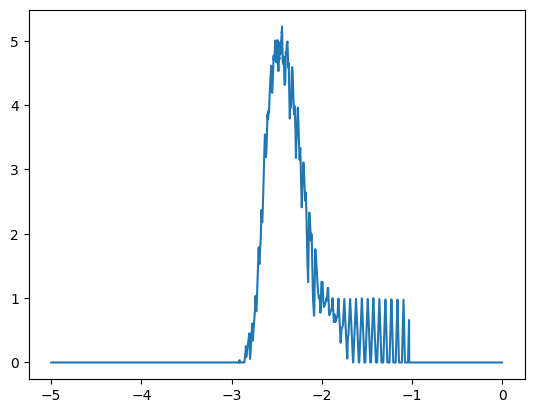

In [4]:
plt.plot(f, score)
plt.show()

In [5]:
f[jp.argmax(score)]

Array(-2.4401855, dtype=float32)

In [14]:
thetas = jax_strategies.sample_trajectories(jax_strategies.FixedForce(-2.5))

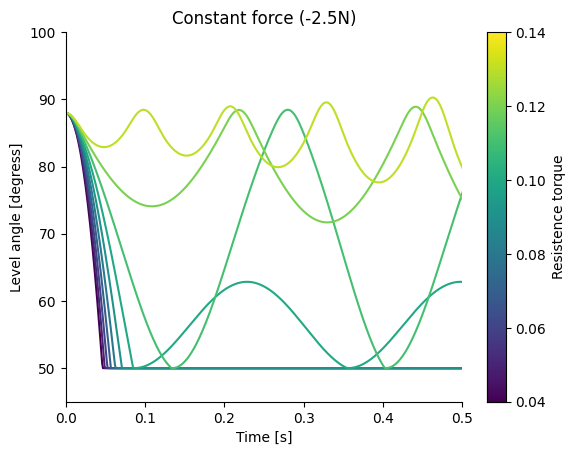

In [15]:
plt.figure()
for i in range(thetas.shape[0]):
    tor = (jp.arange(-0.05, 0.15, 0.01) + 0.1)[i]
    angles = jp.rad2deg(thetas[i])
    seconds = np.arange(thetas.shape[1])/1e3
    color = plt.cm.viridis(i / thetas.shape[0])
    plt.plot(seconds, angles, color=color)
plt.xlim(0, 0.5)
norm = plt.Normalize(vmin=0.04, vmax=0.14)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=plt.gca(), label="Resistence torque")
plt.xlabel("Time [s]")
plt.ylim(45, 100)
plt.ylabel("Level angle [degress]")
plt.title("Constant force (-2.5N)")
sns.despine()
plt.show()

In [8]:
@jax.jit
def eval_pid(kp, ki, kd):
    strategy = jax_strategies.PIDController(kp, ki, kd)
    return jax_strategies.evaluate_strategy(strategy)

In [9]:
best_score = 0
best_vals = None
for kp in tqdm.tqdm(jp.arange(0, 15, 0.1)):
    for ki in jp.arange(0, 0.2, 0.01):
        for kd in jp.arange(0, 1, 0.05):
            score = eval_pid(kp, ki, kd)
            if score > best_score:
                best_score=score
                best_vals = (kp, ki, kd)
best_kp, best_ki, best_kd = best_vals
print(f"Best PID parameters: kp={best_kp:.3f}, ki={best_ki:.3f}, kd={best_kd:.3f}, score={best_score:.3f}")

100%|██████████| 150/150 [08:47<00:00,  3.51s/it]

Best PID parameters: kp=7.000, ki=0.040, kd=0.250, score=39.188


In [16]:
thetas = jax_strategies.sample_trajectories(jax_strategies.PIDController(*best_vals))

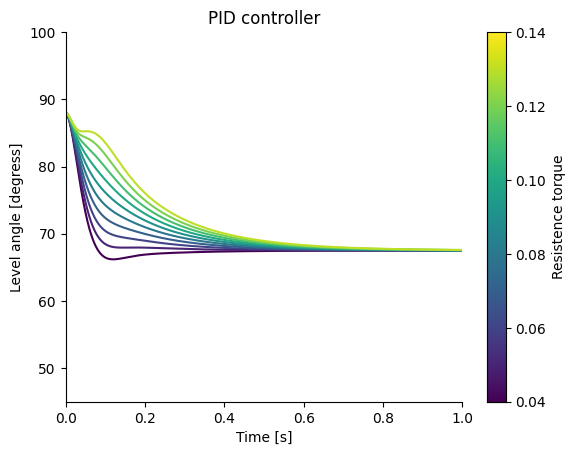

In [17]:
plt.figure()
for i in range(thetas.shape[0]):
    tor = (jp.arange(-0.05, 0.15, 0.01) + 0.1)[i]
    angles = jp.rad2deg(thetas[i])
    seconds = np.arange(thetas.shape[1])/1e3
    color = plt.cm.viridis(i / thetas.shape[0])
    plt.plot(seconds, angles, color=color)
plt.xlim(0, 1.0)
plt.ylim(45, 100)
norm = plt.Normalize(vmin=0.04, vmax=0.14)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=plt.gca(), label="Resistence torque")
plt.xlabel("Time [s]")
plt.ylabel("Level angle [degress]")
plt.title("PID controller")
sns.despine()
plt.show()